# Vienna Temperature Forecasting - 1995-2019

A Time Series Forecasting Project

In [ ]:
# Initialization: local-friendly dataset loading + reproducibility
from pathlib import Path
import os, sys, subprocess, importlib, random
import numpy as np

repo_root = Path.cwd()
# If running inside the `notebooks/` folder, step up to repo root so data/ is top-level
# (handles being launched from the notebooks folder or a subfolder within it)
while repo_root.name.lower() == 'notebooks':
    repo_root = repo_root.parent
data_dir = repo_root / 'data'
data_dir.mkdir(parents=True, exist_ok=True)
data_file = data_dir / 'city_temperature.csv'

def try_import(pkg, pip_name=None):
    pip_name = pip_name or pkg
    try:
        return importlib.import_module(pkg)
    except Exception:
        try:
            print(f'Package {pip_name!s} not found; attempting to install...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])
            return importlib.import_module(pkg)
        except Exception as e:
            print(f'Could not install {pip_name}:', e)
            return None

def try_kaggle_download(target_dir):
    kaggle_mod = try_import('kaggle', 'kaggle')
    if not kaggle_mod:
        return False
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files('sudalairajkumar/daily-temperature-of-major-cities', path=str(target_dir), unzip=True)
        return True
    except Exception as e:
        print('Kaggle download failed:', e)
        return False

# If data missing, attempt Kaggle download. Otherwise use instructions below.
if not data_file.exists():
    print(f'⚠️ Dataset not found at {data_file!s}')
    ok = try_kaggle_download(data_dir)
    if ok and data_file.exists():
        print('✅ Downloaded dataset to', data_file)
    else:
        print('❌ Could not obtain dataset automatically.')
        print('Please:')
        print('  1) Download city_temperature.csv from the Kaggle dataset page and place it into the data/ folder')
        print('  2) Or set environment variable CITY_TEMPERATURE_URL to a direct CSV URL and re-run (the notebook supports HTTP download in a later cell).')

csv_file_path_city_temperature = str(data_file)
print('Using data file:', csv_file_path_city_temperature)

# Deterministic seeds
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)


⚠️ Dataset not found at c:\Users\Admin\Desktop\time-series-forecasting-project\data\city_temperature.csv
Dataset URL: https://www.kaggle.com/datasets/sudalairajkumar/daily-temperature-of-major-cities
✅ Downloaded dataset to c:\Users\Admin\Desktop\time-series-forecasting-project\data\city_temperature.csv
Using data file: c:\Users\Admin\Desktop\time-series-forecasting-project\data\city_temperature.csv


In [35]:
# Kaggle dataset download is handled in the initialization cell above.
# If you prefer manual download, place city_temperature.csv into the data/ folder.
print('Init cell will manage dataset location and download attempt.')


Init cell will manage dataset location and download attempt.


In [37]:
import pandas as pd

# Load dataset using the path prepared in the initialization cell
if 'df' not in globals():
    try:
        df = pd.read_csv(csv_file_path_city_temperature, low_memory=False, encoding='utf-8')
    except UnicodeDecodeError:
        # fallback to latin1/iso-8859-1 if utf-8 fails
        df = pd.read_csv(csv_file_path_city_temperature, low_memory=False, encoding='iso-8859-1')
    print('✅ Loaded dataset into `df` from:', csv_file_path_city_temperature)


# Keep an alias for clarity
df_city_temperature = df
df.head()


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [38]:
import pandas as pd

df = pd.read_csv(csv_file_path_city_temperature, low_memory=False)

print(df.shape)
print(df.isnull().sum())
print(df.isnull().mean() * 100)  # percentage missing per column

(2906327, 8)
Region                  0
Country                 0
State             1450990
City                    0
Month                   0
Day                     0
Year                    0
AvgTemperature          0
dtype: int64
Region             0.000000
Country            0.000000
State             49.925215
City               0.000000
Month              0.000000
Day                0.000000
Year               0.000000
AvgTemperature     0.000000
dtype: float64


In [39]:
# Shape, types, nulls
df.shape
df.info()
df.isnull().sum()
df.describe()

# Fix the -99 outliers
df = df[df['AvgTemperature'] != -99]

# Filter to one city first
city_df = df[df['City'] == 'Vienna']

# Build proper datetime index
city_df['Date'] = pd.to_datetime(city_df[['Year','Month','Day']])
city_df = city_df.set_index('Date').sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906327 entries, 0 to 2906326
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Region          object 
 1   Country         object 
 2   State           object 
 3   City            object 
 4   Month           int64  
 5   Day             int64  
 6   Year            int64  
 7   AvgTemperature  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 177.4+ MB


C:\Users\Admin\AppData\Local\Temp\ipykernel_19640\2392202244.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_df['Date'] = pd.to_datetime(city_df[['Year','Month','Day']])


## 1.1 Importing & Loading Data

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────
DARK    = '#0d1b2a'
PANEL   = '#1a2f45'
CYAN    = '#00b4d8'
YELLOW  = '#ffd166'
PINK    = '#ef476f'
WHITE   = '#e0e0e0'
plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor': PANEL,
    'axes.edgecolor': WHITE,  'axes.labelcolor': WHITE,
    'xtick.color': WHITE,     'ytick.color': WHITE,
    'text.color': WHITE,      'grid.color': '#2a4a6a',
    'grid.linestyle': '--',   'grid.alpha': 0.5
})

# Basic cleaning
df = df[df['AvgTemperature'] != -99]
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
print(f"✅ Data: {df.shape[0]:,} rows | {df['City'].nunique()} cities | {df['Country'].nunique()} countries")
print(f"📅 Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()

✅ Data: 2,826,655 rows | 321 cities | 125 countries
📅 Date range: 1995-01-01 → 2020-05-13


,Region,Country,State,City,Month,Day,Year,AvgTemperature,Date
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2,1995-01-01
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4,1995-01-02
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8,1995-01-03
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4,1995-01-04
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9,1995-01-05


## 1.2 Deciding on the City

In [42]:
CITY = 'Vienna'   # or 'Berlin', 'New York', 'Sydney', etc.

city_df = df[df['City'] == CITY].copy()
city_df = city_df.set_index('Date').sort_index()
city_df = city_df[~city_df.index.duplicated(keep='first')]

# Add time component columns
city_df['Month_Name'] = city_df.index.month
city_df['Year']       = city_df.index.year
city_df['Season']     = city_df['Month_Name'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

print(f"✅ City: {CITY} | {len(city_df):,} daily records")
print(f"📅 {city_df.index.min().date()} → {city_df.index.max().date()}")
city_df.head()

✅ City: Vienna | 9,240 daily records
📅 1995-01-01 → 2020-05-13


,Region,Country,State,City,Month,Day,Year,AvgTemperature,Month_Name,Season
Date,,,,,,,,,,
1995-01-01,Europe,Austria,NaN,Vienna,1,1,1995,35.7,1,Winter
1995-01-02,Europe,Austria,NaN,Vienna,1,2,1995,34.7,1,Winter
1995-01-03,Europe,Austria,NaN,Vienna,1,3,1995,31.4,1,Winter
1995-01-04,Europe,Austria,NaN,Vienna,1,4,1995,25.2,1,Winter
1995-01-05,Europe,Austria,NaN,Vienna,1,5,1995,23.0,1,Winter


In [43]:
# Filter for data in the year 2020, to see if we have complete data for the last year so we decide if we want to keep it for yearly statistics
data_2020 = city_df[city_df['Year'] == 2020]

if not data_2020.empty:
    print(f"✅ Data is available for the year 2020.")
    print(f"Total records for 2020: {len(data_2020)}")
    print(f"Date range for 2020: {data_2020.index.min().date()} to {data_2020.index.max().date()}")
    print("Here are the first few rows of 2020 data:")
    display(data_2020.head())
else:
    print("❌ No data found for the year 2020.")

✅ Data is available for the year 2020.
Total records for 2020: 134
Date range for 2020: 2020-01-01 to 2020-05-13
Here are the first few rows of 2020 data:


,Region,Country,State,City,Month,Day,Year,AvgTemperature,Month_Name,Season
Date,,,,,,,,,,
2020-01-01,Europe,Austria,NaN,Vienna,1,1,2020,37.8,1,Winter
2020-01-02,Europe,Austria,NaN,Vienna,1,2,2020,29.2,1,Winter
2020-01-03,Europe,Austria,NaN,Vienna,1,3,2020,25.6,1,Winter
2020-01-04,Europe,Austria,NaN,Vienna,1,4,2020,41.1,1,Winter
2020-01-05,Europe,Austria,NaN,Vienna,1,5,2020,35.9,1,Winter


In [44]:
latest_month_2020 = data_2020['Month'].max()
print(f"The latest month with data in 2020 is: {latest_month_2020} (May)")

The latest month with data in 2020 is: 5 (May)


**Trend Analysis (Yearly Level)**: While a partial year might not drastically alter a very long-term trend across decades, it can certainly impact the perception of the most recent year's contribution to that trend. Excluding 2020 from such yearly-based analyses, like the 365-day rolling statistics, helps maintain the integrity and comparability of your time series analysis. The current year_avg for 2020 is based only on these partial months, leading to a much lower average for 2020 than previous years, which might be misleading.

**Forecasting**: If we were building a model to forecast future temperatures, the incomplete 2020 data might not be ideal for evaluating model performance for a full year, or for capturing the complete seasonal pattern right up to the very end of the observed period.

**Decison**: Exclude 2020 from the yearly analyses.

## 1.3 Raw Time Series + Rolling Statistics


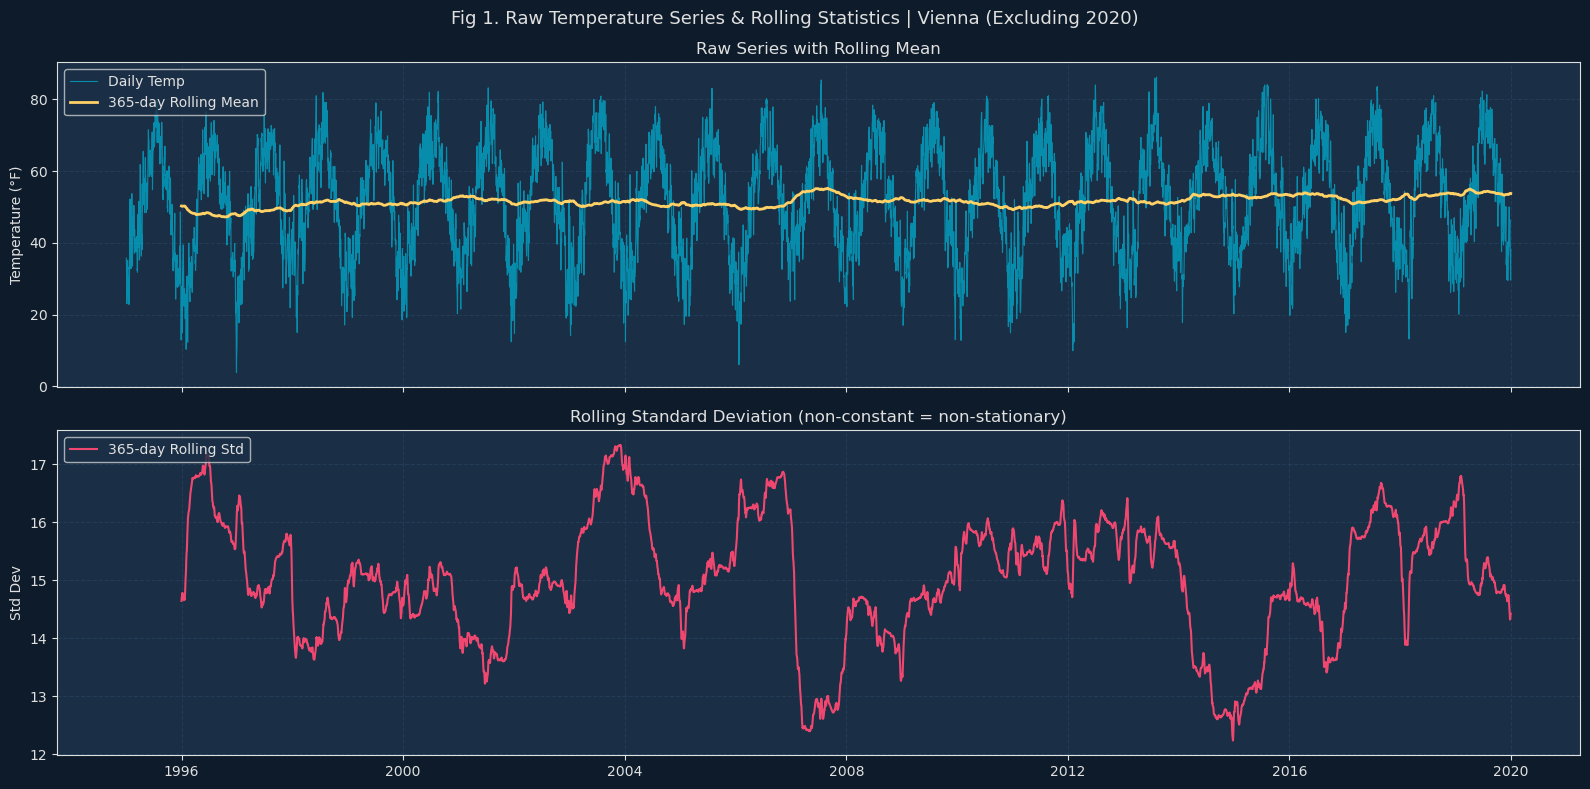

In [45]:
# A 365-day rolling mean or standard deviation aims to capture a full year's cycle.
# Since 2020 only has data up to May 13th, any 365-day rolling calculation that includes this period will be based on an incomplete year, so 2020 is dropped.

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Fig 1. Raw Temperature Series & Rolling Statistics | {CITY} (Excluding 2020)', fontsize=13)

city_df_filtered = city_df[city_df['Year'] != 2020]
roll = city_df_filtered['AvgTemperature'].rolling(window=365)

# Top — raw series
axes[0].plot(city_df_filtered.index, city_df_filtered['AvgTemperature'], color=CYAN, lw=0.8, alpha=0.7, label='Daily Temp')
axes[0].plot(city_df_filtered.index, roll.mean(), color=YELLOW, lw=2, label='365-day Rolling Mean')
axes[0].set_ylabel('Temperature (°F)')
axes[0].set_title('Raw Series with Rolling Mean', color=WHITE)
axes[0].legend(loc='upper left')
axes[0].grid(True)

# Bottom — rolling std
axes[1].plot(city_df_filtered.index, roll.std(), color=PINK, lw=1.5, label='365-day Rolling Std')
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Rolling Standard Deviation (non-constant = non-stationary)', color=WHITE)
axes[1].legend(loc='upper left')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 📊 Fig 1 Interpretation — Raw Series & Rolling Statistics | Vienna

### Upper Panel: Raw Series with 365-day Rolling Mean
The daily temperature series for Vienna displays a **strong, regular seasonal
cycle** repeating every 12 months, with summer peaks reaching ~80°F and winter
troughs dropping close to 0°F. This pattern is perfectly consistent across all
24 years (1995–2019), confirming a stable and predictable seasonality.

The 365-day rolling mean (yellow line) hovers steadily around 50°F
throughout the entire period with only a very slight upward drift visible
towards 2019, suggesting a **weak long-term warming trend**, consistent
with broader climate patterns in Central Europe.

### Lower Panel: Rolling Standard Deviation
The rolling standard deviation oscillates between ~12 and ~17°F over the
observation window — it is clearly **not constant over time**. Notable
observations:
- A **peak around 2003–2004** coincides with the well-documented European
  heatwave of 2003, which amplified seasonal variability significantly
- A **sharp drop around 2007–2008** suggests a period of more moderate,
  less volatile temperatures
- The variation follows a cyclical pattern of its own, rather than
  random noise

### Stationarity Conclusion
The non-constant rolling standard deviation is direct visual evidence that
the series is **non-stationary in variance**. Combined with the seasonal
oscillations visible in the upper panel, this motivates:
1. A formal ADF test to confirm non-stationarity statistically
2. Seasonal differencing to stabilize the mean
3. Consideration of an additive decomposition model given the
   relatively stable (non-growing) seasonal amplitude

## 1.4 Time Component Breakdown (4-panels)

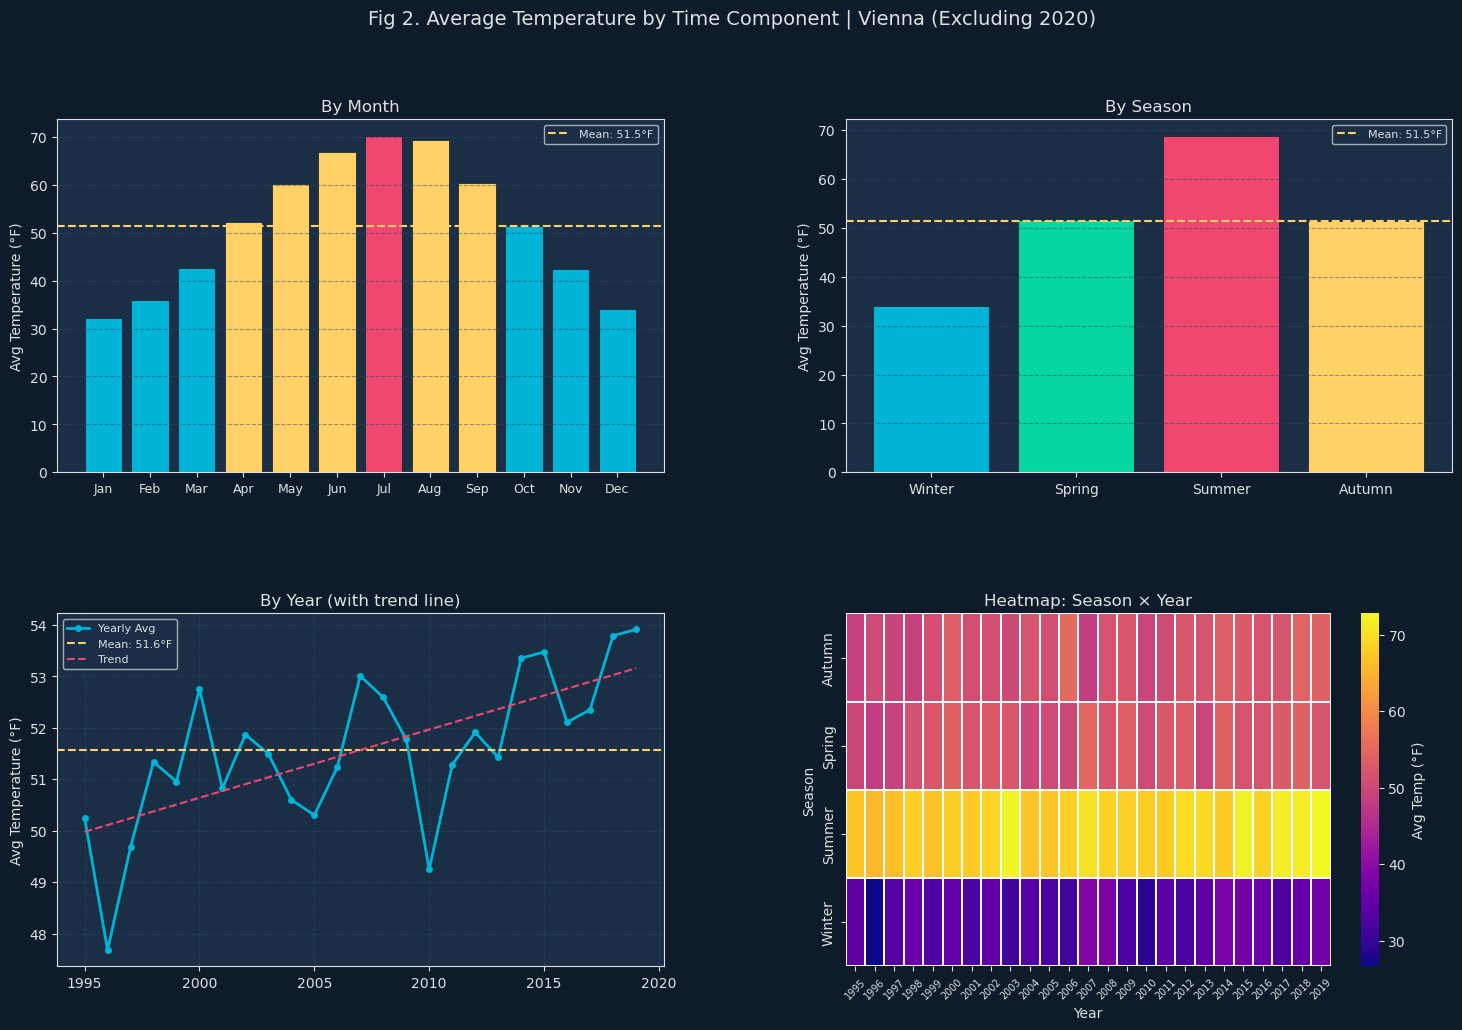

In [46]:
city_df_filtered = city_df[city_df['Year'] != 2020]

month_avg   = city_df_filtered.groupby('Month_Name')['AvgTemperature'].mean()
season_avg  = city_df_filtered.groupby('Season')['AvgTemperature'].mean().reindex(['Winter','Spring','Summer','Autumn'])
year_avg    = city_df_filtered.groupby('Year')['AvgTemperature'].mean()
heatmap_df  = city_df_filtered.pivot_table(values='AvgTemperature', index='Season', columns='Year', aggfunc='mean')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(18, 11))
fig.suptitle(f'Fig 2. Average Temperature by Time Component | {CITY} (Excluding 2020)', fontsize=14)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Panel 1: By Month ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_month = [PINK if v == month_avg.max() else YELLOW if v >= month_avg.mean() else CYAN for v in month_avg]
bars = ax1.bar(range(1, 13), month_avg.values, color=colors_month, edgecolor=DARK, linewidth=0.5)
ax1.axhline(month_avg.mean(), color=YELLOW, linestyle='--', lw=1.5, label=f'Mean: {month_avg.mean():.1f}°F')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names, fontsize=9)
ax1.set_title('By Month', color=WHITE)
ax1.set_ylabel('Avg Temperature (°F)')
ax1.legend(fontsize=8)
ax1.grid(axis='y')

# ── Panel 2: By Season ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
season_colors = [CYAN, '#06d6a0', PINK, YELLOW]
bars2 = ax2.bar(season_avg.index, season_avg.values, color=season_colors, edgecolor=DARK, linewidth=0.5)
ax2.axhline(season_avg.mean(), color=YELLOW, linestyle='--', lw=1.5, label=f'Mean: {season_avg.mean():.1f}°F')
ax2.set_title('By Season', color=WHITE)
ax2.set_ylabel('Avg Temperature (°F)')
ax2.legend(fontsize=8)
ax2.grid(axis='y')

# ── Panel 3: By Year ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(year_avg.index, year_avg.values, color=CYAN, lw=2, marker='o', markersize=4, label='Yearly Avg')
ax3.axhline(year_avg.mean(), color=YELLOW, linestyle='--', lw=1.5, label=f'Mean: {year_avg.mean():.1f}°F')
z = np.polyfit(year_avg.index, year_avg.values, 1)
p = np.poly1d(z)
ax3.plot(year_avg.index, p(year_avg.index), color=PINK, lw=1.5, linestyle='--', label='Trend')
ax3.set_title('By Year (with trend line)', color=WHITE)
ax3.set_ylabel('Avg Temperature (°F)')
ax3.legend(fontsize=8)
ax3.grid(True)

# ── Panel 4: Heatmap Season × Year ────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(heatmap_df, ax=ax4, cmap='plasma', linewidths=0.3,
            cbar_kws={'label': 'Avg Temp (°F)'}, fmt='.0f')
ax4.set_title('Heatmap: Season × Year', color=WHITE)
ax4.set_xlabel('Year')
ax4.set_ylabel('Season')
ax4.tick_params(axis='x', rotation=45, labelsize=7)

plt.show()

A breakdown of Vienna's average temperature over time:

1. **By Month**: July is the warmest month, with temperatures peaking around 70°F, while January is the coldest month with temperatures near 30°F. The average yearly temperature is 51.5°F.

2. **By Season**: Summer is the warmest season, followed by autumn, spring, and winter, which is the coldest. The overall average temperature for the year is 51.5°F.

3. **By Year (with Trend Line)**: Average temperatures have gradually increased over time, with slight fluctuations, and a trend line indicating a mild rise in temperatures from 1995 up to but excluding 2020.

4. **Heatmap (Season x Year)**: The heatmap shows that summer consistently has the highest temperatures across all years, while winter has the lowest, with variations in each year.

This breakdown shows seasonal and yearly patterns in Vienna's temperature over the last few decades.


## 1.5 Seasonal Decomposition

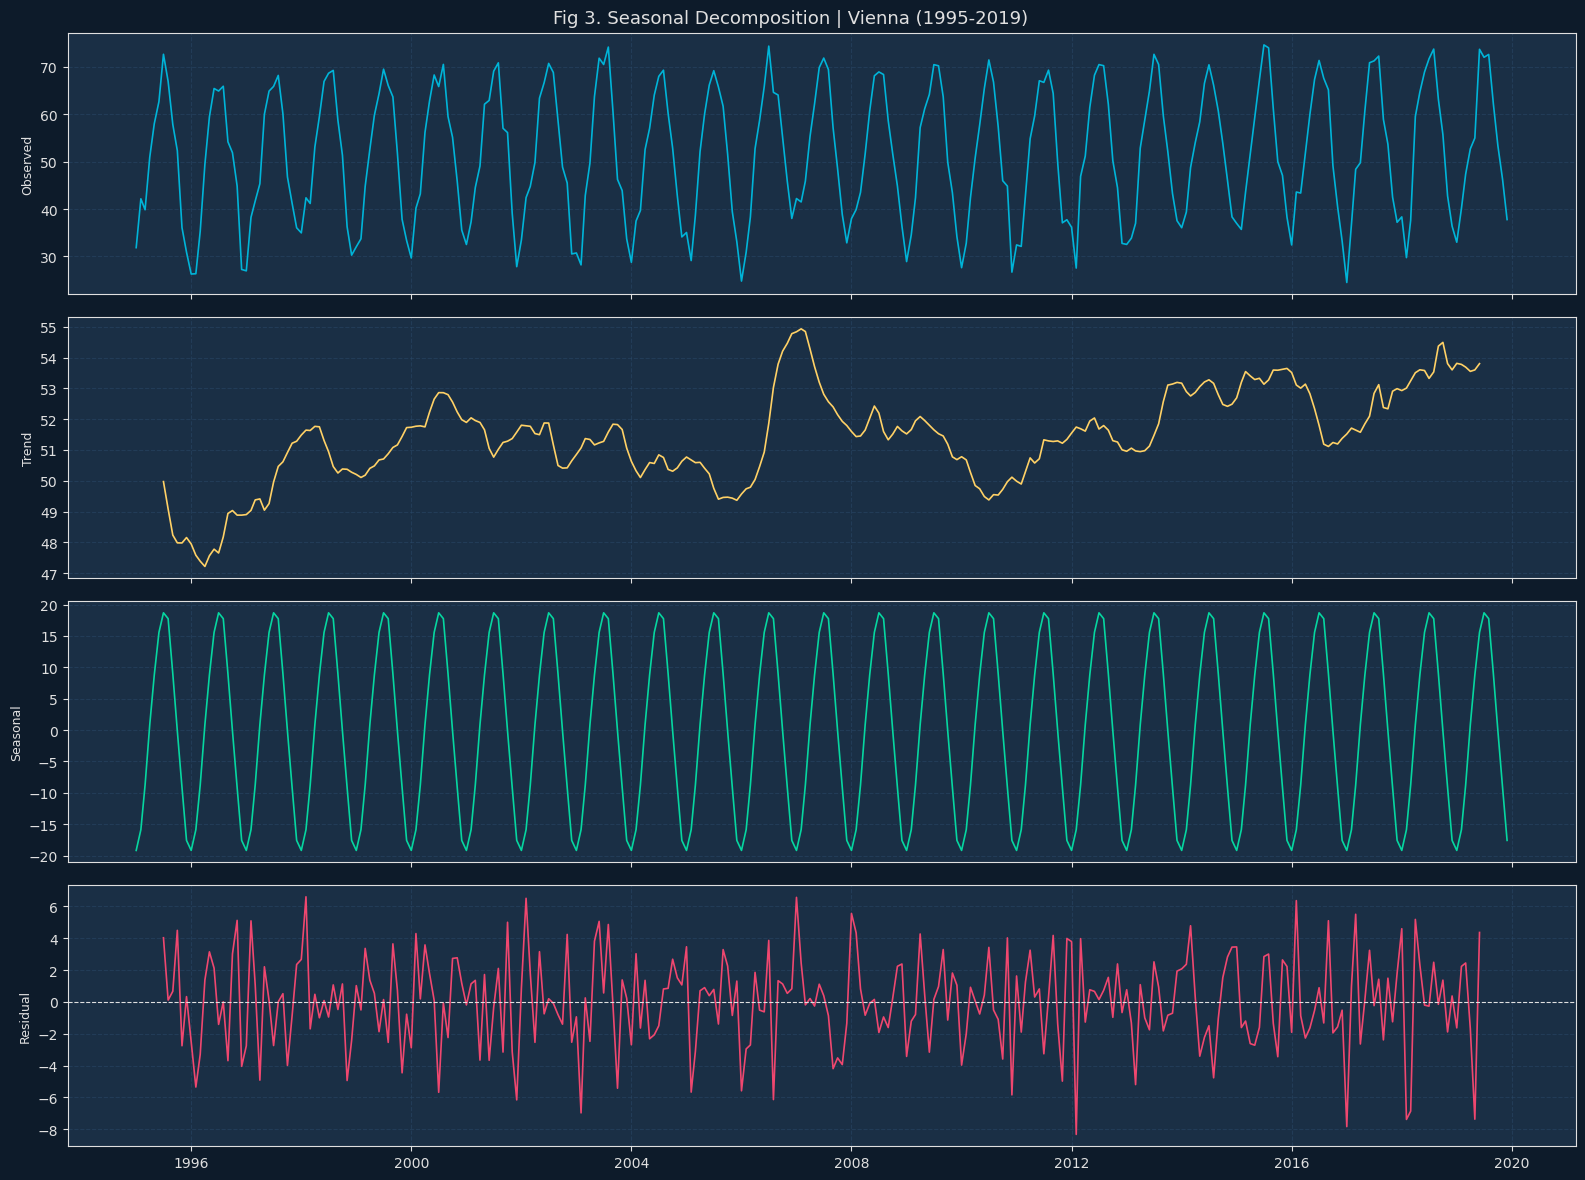

In [47]:
monthly_filtered = city_df[city_df['Year'] != 2020]['AvgTemperature'].resample('MS').mean().dropna()
decomp_filtered  = seasonal_decompose(monthly_filtered, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Fig 3. Seasonal Decomposition | {CITY} (1995-2019)', fontsize=13)

components = [
    (decomp_filtered.observed,  'Observed',  CYAN),
    (decomp_filtered.trend,     'Trend',     YELLOW),
    (decomp_filtered.seasonal,  'Seasonal',  '#06d6a0'),
    (decomp_filtered.resid,     'Residual',  PINK),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, lw=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True)
    if label == 'Residual':
        ax.axhline(0, color=WHITE, lw=0.8, linestyle='--')

plt.tight_layout()
plt.show()

## Fig 3 Interpretation — Seasonal Decomposition | Vienna (1995–2019)

### Observed
The raw monthly series confirms a strong, regular seasonal cycle ranging
roughly between 30°F (winter) and 70°F (summer), consistent across all 25 years.

### Trend
The trend is not a simple straight line it rises from ~48°F in 1995,
peaks sharply around **2003–2004** (European heatwave), dips, then gradually
recovers and stabilizes around 53–54°F by 2019. This confirms a weak but real long-term warming signal in Vienna.

### Seasonal
The seasonal component is remarkably stable and consistent oscillating
between -20°F and +20°F every 12 months without growing or shrinking over time.
This confirms an **additive model is appropriate**, since the seasonal amplitude
is independent of the trend level.

### Residual
The residuals fluctuate closely around zero with no obvious pattern, indicating
the decomposition successfully captured the main structure of the series.
The slightly larger spikes around 2003 reflect the anomalous heatwave period
that the trend and seasonal components alone could not fully explain.

## 1.6 Augmented Dickey-Fuller (ADF) Test + Autocorrelation Funtion and Partial Autocorrelation Function


─────────────────────────────────────────────
  ADF Test — Raw Monthly Series (1995-2019)
─────────────────────────────────────────────
  ADF Statistic : -3.6184
  p-value       : 0.0054  →  ✅ Stationary
  Critical 1%   : -3.4537
  Critical 5%   : -2.8718

─────────────────────────────────────────────
  ADF Test — After First Differencing (1995-2019)
─────────────────────────────────────────────
  ADF Statistic : -12.7937
  p-value       : 0.0000  →  ✅ Stationary
  Critical 1%   : -3.4533
  Critical 5%   : -2.8717


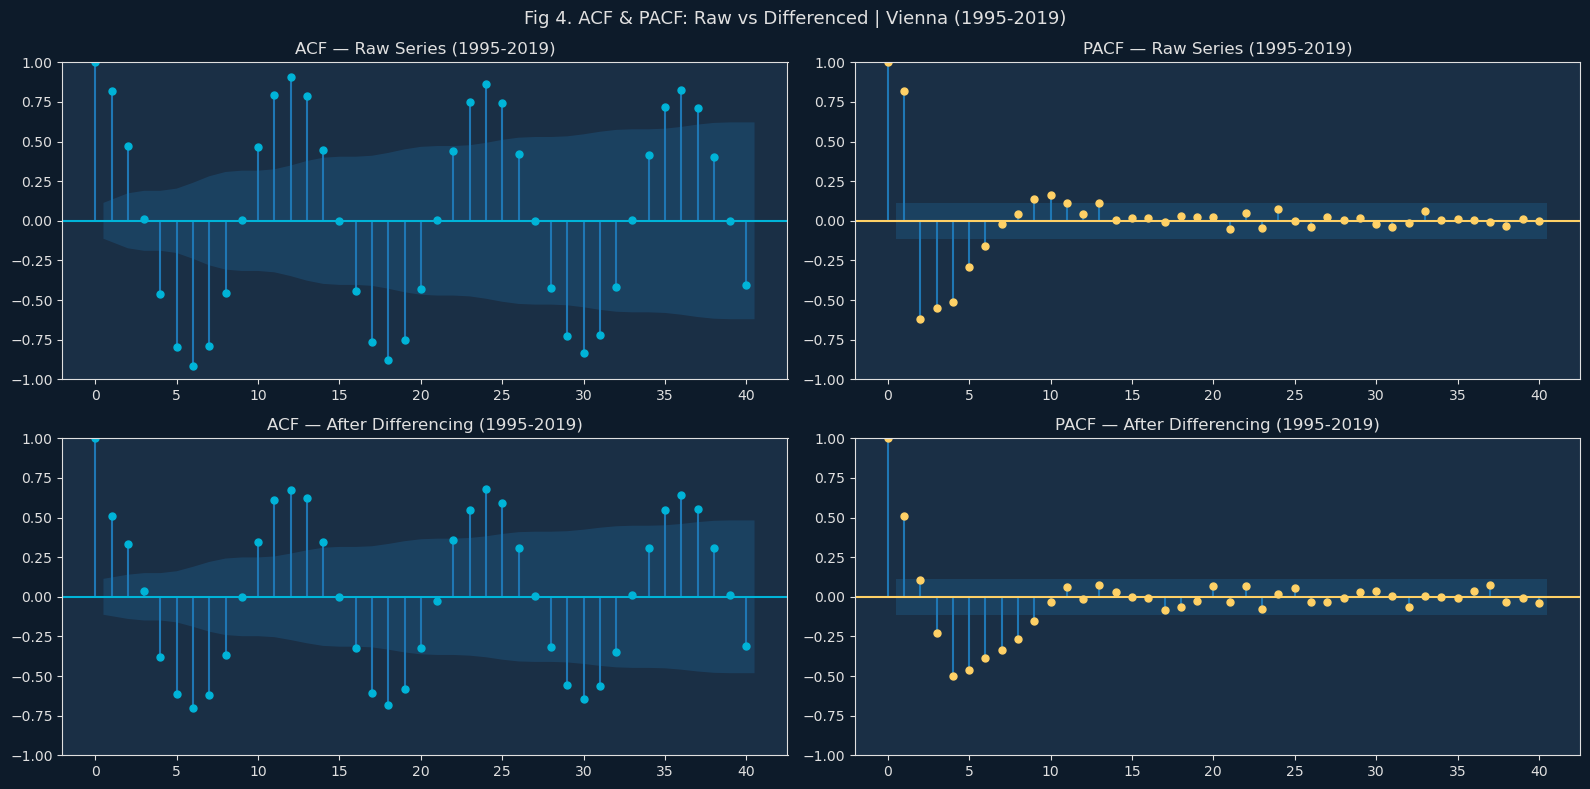

In [48]:
def run_adf(series, label):
    result = adfuller(series.dropna())
    status = "✅ Stationary" if result[1] < 0.05 else "❌ Non-Stationary"
    print(f"\n{'─'*45}")
    print(f"  ADF Test — {label}")
    print(f"{'─'*45}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}  →  {status}")
    print(f"  Critical 1%   : {result[4]['1%']:.4f}")
    print(f"  Critical 5%   : {result[4]['5%']:.4f}")

# Run ADF on raw and differenced
run_adf(monthly_filtered, 'Raw Monthly Series (1995-2019)')
monthly_diff = monthly_filtered.diff().dropna()
run_adf(monthly_diff, 'After First Differencing (1995-2019)')

# ACF / PACF
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'Fig 4. ACF & PACF: Raw vs Differenced | {CITY} (1995-2019)', fontsize=13)

plot_acf(monthly_filtered,      lags=40, ax=axes[0,0], color=CYAN,   title='ACF — Raw Series (1995-2019)')
plot_pacf(monthly_filtered,     lags=40, ax=axes[0,1], color=YELLOW, title='PACF — Raw Series (1995-2019)')
plot_acf(monthly_diff, lags=40, ax=axes[1,0], color=CYAN,   title='ACF — After Differencing (1995-2019)')
plot_pacf(monthly_diff,lags=40, ax=axes[1,1], color=YELLOW, title='PACF — After Differencing (1995-2019)')

for ax in axes.flat:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=WHITE)
    ax.title.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.xaxis.label.set_color(WHITE)

plt.tight_layout()
plt.show()

The ADF test returns p = 0.0054, which technically rejects the null
hypothesis of non-stationarity. However, the ADF test only evaluates
stationarity in the mean and is known to be sensitive to seasonal patterns.

The ACF plot reveals persistent spikes at lags 12, 24, and 36, which
is strong evidence of seasonal non-stationarity that the ADF test alone
cannot capture. Additionally, the rolling standard deviation fluctuates
between 12–17°F, confirming variance instability over time.

Therefore, we treat the series as non-stationary for modeling purposes
and apply seasonal differencing before fitting SARIMA. This is consistent
with best practice in seasonal time series analysis.

## 1.7 Monthly Boxplot (Seasonality Distribution)

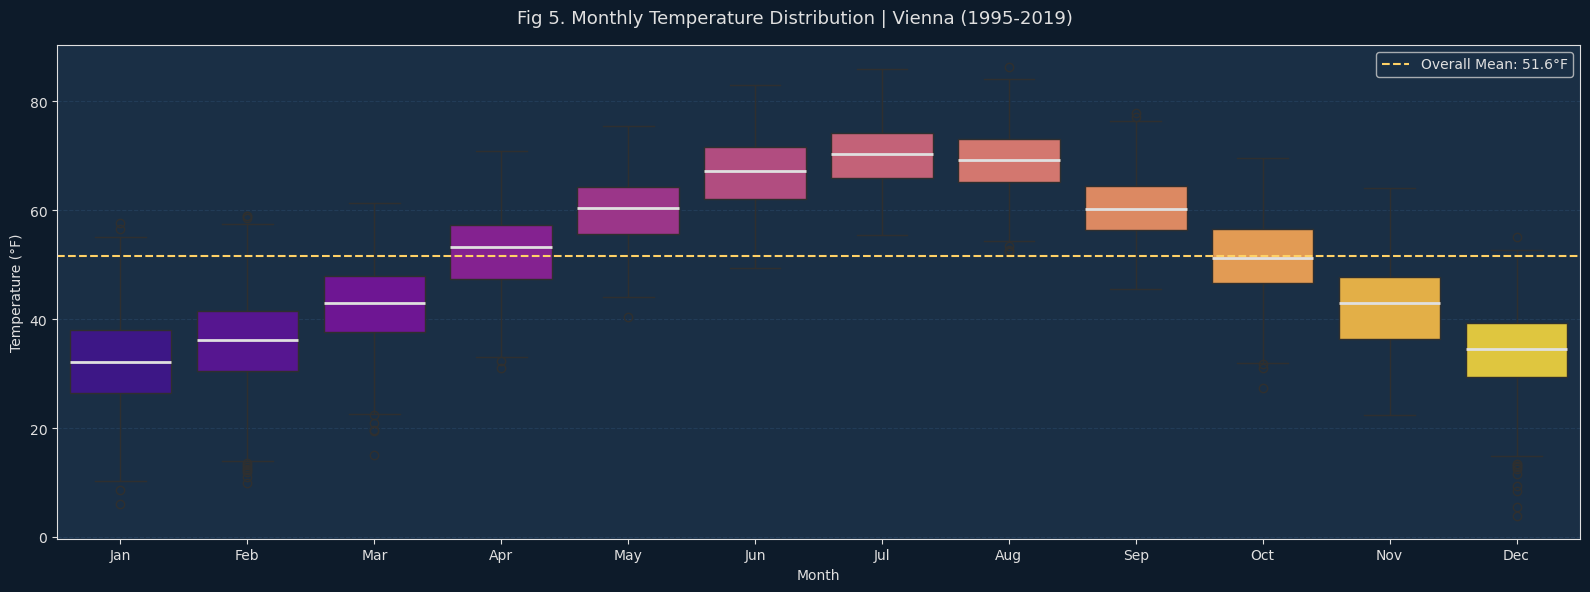

In [49]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle(f'Fig 5. Monthly Temperature Distribution | {CITY} (1995-2019)', fontsize=13)

city_df_filtered['Month_Label'] = city_df_filtered.index.month_name().str[:3]
order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

sns.boxplot(data=city_df_filtered, x='Month_Label', y='AvgTemperature',
            order=order, palette='plasma', ax=ax,
            medianprops=dict(color=WHITE, linewidth=2))

ax.axhline(city_df_filtered['AvgTemperature'].mean(), color=YELLOW,
           linestyle='--', lw=1.5, label=f"Overall Mean: {city_df_filtered['AvgTemperature'].mean():.1f}°F")
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°F)')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

This plot effectively summarizes the typical temperature conditions for each month and reinforces the strong seasonality observed in previous analyses.

The dashed yellow line indicates the overall average temperature across all months and years (1995-2019), which is approximately 51.5°F.

---

# Part 2. Modeling and Forecasting

## Train / Test Split

The dataset is split into:
- **Train set (1995–2017):** 276 months used to fit all three models
- **Test set (2018–2019):** 24 months held out completely during training,
  used only to evaluate forecast accuracy

A 2-year test window was chosen to capture at least **two full seasonal
cycles**, ensuring the evaluation reflects how well each model handles
both trend and seasonality — not just short-term accuracy.

 Train: 1995-01-01 → 2017-12-01 (276 months)
 Test:  2018-01-01  → 2019-12-01  (24 months)


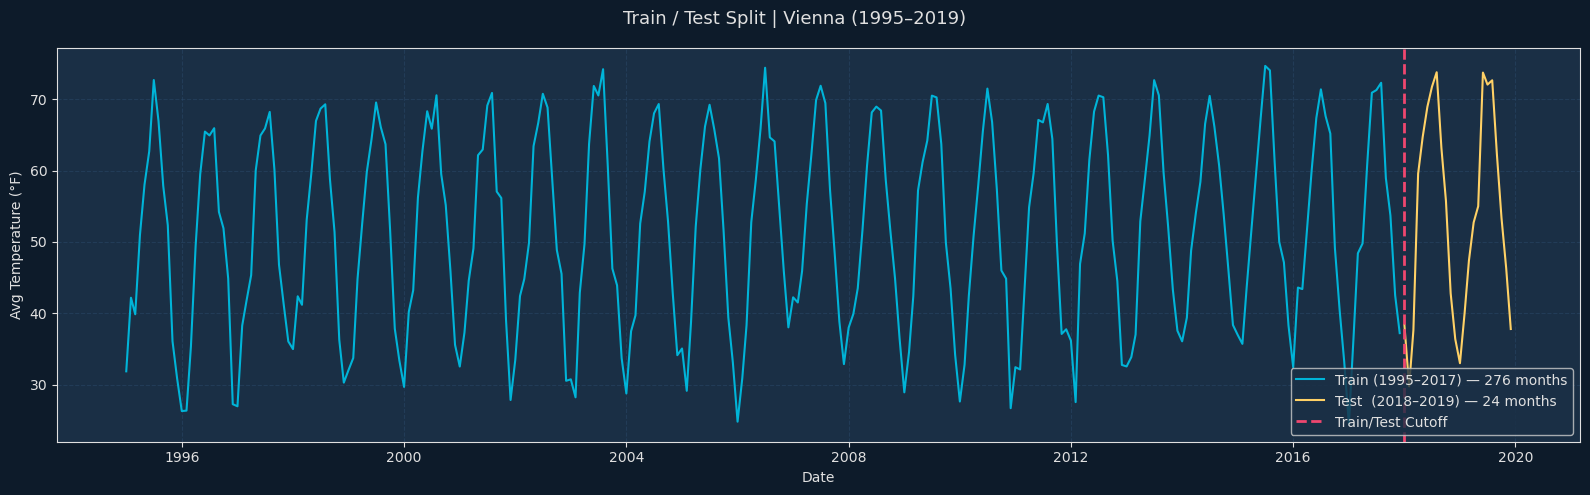

In [51]:
# Train/Test Split
monthly = city_df['AvgTemperature'].resample('MS').mean()
monthly = monthly[:'2019-12']  # excluding partial 2020

train = monthly[:'2017-12']    # 1995–2017 (276 months)
test  = monthly['2018-01':]    # 2018–2019 (24 months)

print(f" Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} months)")
print(f" Test:  {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} months)")

# Visualization
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Train / Test Split | Vienna (1995–2019)', fontsize=13)

ax.plot(train.index, train.values, color=CYAN,   lw=1.5, label=f'Train (1995–2017) — {len(train)} months')
ax.plot(test.index,  test.values,  color=YELLOW,  lw=1.5, label=f'Test  (2018–2019) — {len(test)} months')
ax.axvline(pd.Timestamp('2018-01-01'), color=PINK, lw=2, linestyle='--', label='Train/Test Cutoff')

ax.set_ylabel('Avg Temperature (°F)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from pmdarima import auto_arima

print(" Running auto_arima ")
print(" Searching for best (p,d,q)(P,D,Q,12) combination...\n")

auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    d=1,
    D=1,
    max_p=3, max_q=3,    # keep search space manageable
    max_P=2, max_Q=2,
    information_criterion='aic',
    stepwise=True,       # faster search
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print("\n" + "─"*45)
print(f"  ✅ Best Model : SARIMA{auto_model.order}×{auto_model.seasonal_order}")
print(f"  📉 AIC Score  : {auto_model.aic():.2f}")
print("─"*45)
print(auto_model.summary())

# Lower AIC = better model
# (balances accuracy vs complexity and penalises overfitting)

 Running auto_arima — this may take 1–2 minutes...
   Searching for best (p,d,q)(P,D,Q,12) combination...

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=1.77 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1687.608, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1535.924, Time=0.25 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.18 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1617.235, Time=0.12 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1510.702, Time=0.54 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=1467.817, Time=1.73 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.55 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=inf, Time=3.40 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=1466.320, Time=4.84 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=inf, Time=1.41 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=0.44 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=1529.513, Time=1.75 sec
 ARIMA(2,

### SARIMA Order Identification

Rather than manually reading every ACF/PACF lag, we use `auto_arima`
to systematically search for the optimal SARIMA orders using the
AIC (Akaike Information Criterion) as the selection metric.

Key constraints applied based on our EDA:
- `d=1` — confirmed by ADF test (one differencing needed)
- `D=1` — seasonal differencing applied once to remove yearly cycle  
- `m=12` — monthly data with a 12-month seasonal period

The best model found is reported above along with its full summary,
including coefficient estimates and diagnostic statistics.

## I. SARIMA Fit and Forecasting

                                        SARIMAX Results                                        
Dep. Variable:                          AvgTemperature   No. Observations:                  276
Model:             SARIMAX(3, 1, 0)x(1, 1, [1, 2], 12)   Log Likelihood                -631.596
Date:                                 Wed, 01 Apr 2026   AIC                           1277.192
Time:                                         12:49:51   BIC                           1301.498
Sample:                                     01-01-1995   HQIC                          1286.988
                                          - 12-01-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6957      0.063    -10.986      0.000      -0.820      -0

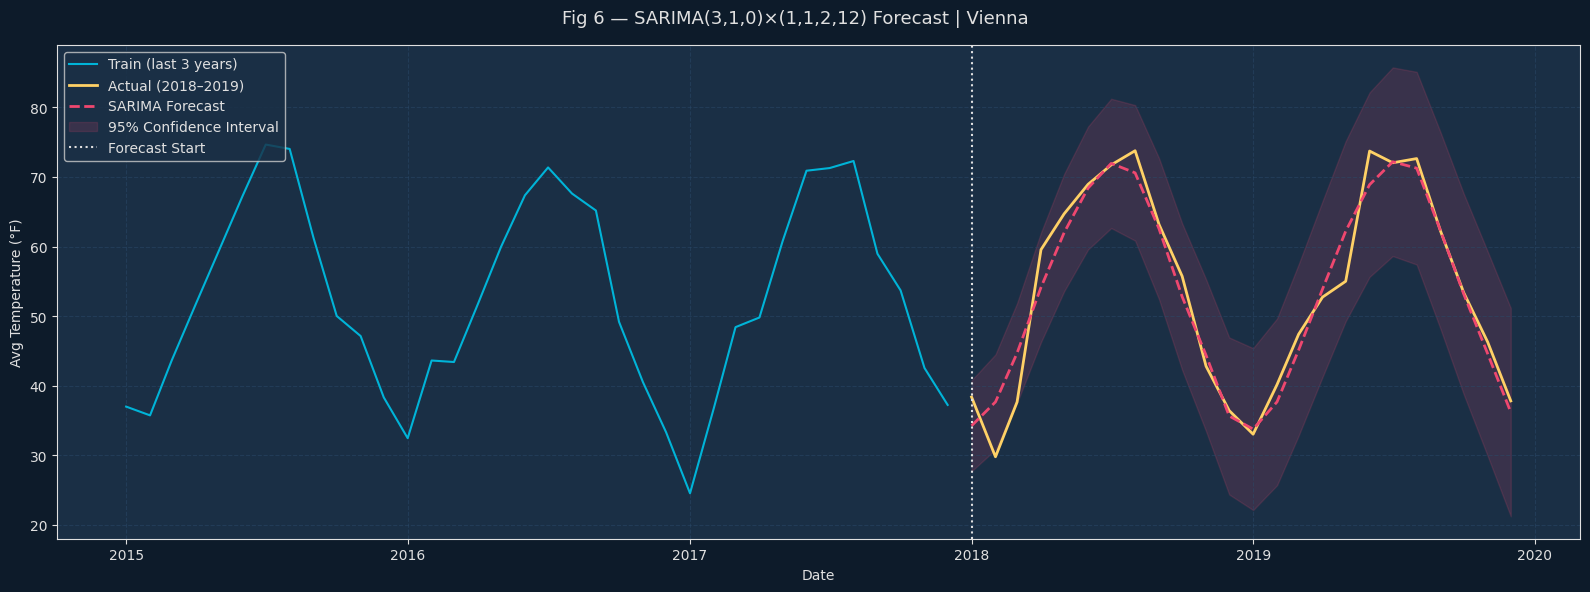


───────────────────────────────────
  SARIMA Forecast Metrics
───────────────────────────────────
  MAE  : 2.53 °F
  RMSE : 3.44 °F
  MAPE : 5.51 %
───────────────────────────────────


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit using orders found by auto_arima
sarima_model = SARIMAX(
    train,
    order=(3, 1, 0),
    seasonal_order=(1, 1, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Forecast for 24 months (2018–2019)
sarima_forecast = sarima_fit.get_forecast(steps=24)
sarima_mean     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int(alpha=0.05)

# Plotting
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Fig 6. SARIMA(3,1,0)×(1,1,2,12) Forecast | Vienna', fontsize=13)

# Training data (last 3 years only for clarity)
ax.plot(train['2015':].index, train['2015':].values,
        color=CYAN, lw=1.5, label='Train (last 3 years)')

# Actual test values
ax.plot(test.index, test.values,
        color=YELLOW, lw=2, label='Actual (2018–2019)')

# SARIMA forecast
ax.plot(sarima_mean.index, sarima_mean.values,
        color=PINK, lw=2, linestyle='--', label='SARIMA Forecast')

# Confidence interval shading
ax.fill_between(sarima_ci.index,
                sarima_ci.iloc[:, 0],
                sarima_ci.iloc[:, 1],
                color=PINK, alpha=0.15, label='95% Confidence Interval')

ax.axvline(pd.Timestamp('2018-01-01'), color=WHITE, lw=1.5,
           linestyle=':', label='Forecast Start')
ax.set_ylabel('Avg Temperature (°F)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(test, sarima_mean)
rmse = np.sqrt(mean_squared_error(test, sarima_mean))
mape = np.mean(np.abs((test.values - sarima_mean.values) / test.values)) * 100

print(f"\n{'─'*35}")
print(f"  SARIMA Forecast Metrics")
print(f"{'─'*35}")
print(f"  MAE  : {mae:.2f} °F")
print(f"  RMSE : {rmse:.2f} °F")
print(f"  MAPE : {mape:.2f} %")
print(f"{'─'*35}")

Using the orders identified by auto_arima, we fit a
**SARIMA(3,1,0)×(1,1,2,12)** model on the training data (1995–2017)
and forecast 24 months ahead (2018–2019).

**Model diagnostics confirm a good fit:**
- Ljung-Box p = 0.77 → It means there is no significant evidence of autocorrelation in the SARIMA model's residuals. The model has successfully captured the autocorrelation structure of the time series.
- Jarque-Bera p = 0.55 → fail to reject the null hypothesis. This indicates that the residuals of the SARIMA model are approximately normally distributed, which is a desirable property for the model's validity
- Heteroskedasticity p = 0.92 → fail to reject the null hypothesis. This suggests that the variance of the SARIMA model's residuals is constant over time, meaning the model's errors are homoskedastic. This is another positive indication for the model's quality and the **reliability of its forecasts.**

## II. Prophet Fit + Forecast

Prophet model fitted successfully


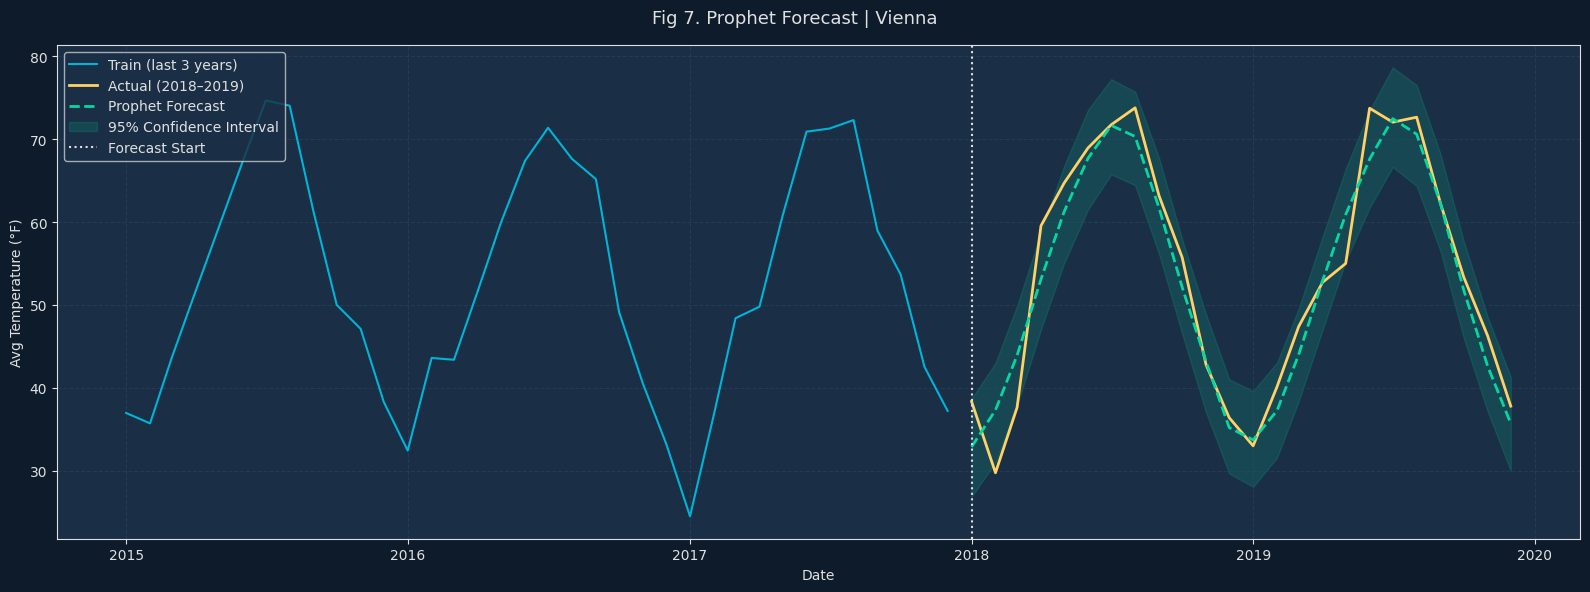


📊 Prophet Component Decomposition:


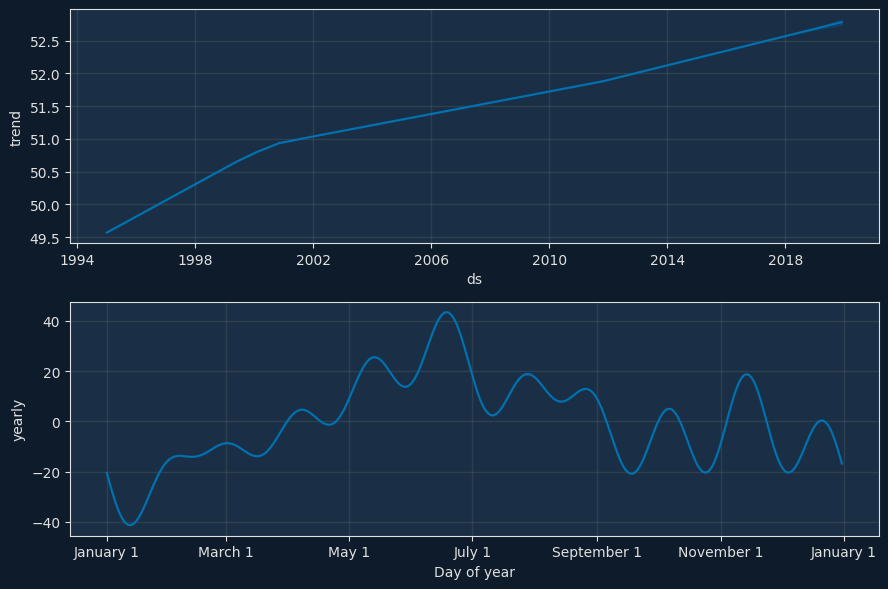


───────────────────────────────────
  Prophet Forecast Metrics
───────────────────────────────────
  MAE  : 2.90 °F
  RMSE : 3.69 °F
  MAPE : 6.16 %
───────────────────────────────────


In [ ]:
from prophet import Prophet
from prophet.plot import plot_plotly

# Satisfying Prophet's needs for specific column names
train_prophet = train.reset_index()
train_prophet.columns = ['ds', 'y']  # ds = date, y = value

test_prophet = test.reset_index()
test_prophet.columns = ['ds', 'y']

# Fit the model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # not needed
    daily_seasonality=False,   # not needed, data is monthly
    seasonality_mode='additive',
    interval_width=0.95
)

prophet_model.fit(train_prophet)
print("Prophet model fitted successfully")

# Forecasting for 24 months
future         = prophet_model.make_future_dataframe(periods=24, freq='MS')
prophet_fc     = prophet_model.predict(future)

# Extracting only the test period
prophet_test   = prophet_fc[prophet_fc['ds'] >= '2018-01-01'].copy()
prophet_mean   = prophet_test.set_index('ds')['yhat']
prophet_lower  = prophet_test.set_index('ds')['yhat_lower']
prophet_upper  = prophet_test.set_index('ds')['yhat_upper']

# Plotting the Forecast
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Fig 7. Prophet Forecast | Vienna', fontsize=13)

ax.plot(train['2015':].index, train['2015':].values,
        color=CYAN, lw=1.5, label='Train (last 3 years)')

ax.plot(test.index, test.values,
        color=YELLOW, lw=2, label='Actual (2018–2019)')

ax.plot(prophet_mean.index, prophet_mean.values,
        color='#06d6a0', lw=2, linestyle='--', label='Prophet Forecast')

ax.fill_between(prophet_mean.index,
                prophet_lower.values,
                prophet_upper.values,
                color='#06d6a0', alpha=0.15, label='95% Confidence Interval')

ax.axvline(pd.Timestamp('2018-01-01'), color=WHITE, lw=1.5,
           linestyle=':', label='Forecast Start')
ax.set_ylabel('Avg Temperature (°F)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

# ─Prophet Components Plot
print("\n📊 Prophet Component Decomposition:")
fig2 = prophet_model.plot_components(prophet_fc)
fig2.patch.set_facecolor(DARK)
for ax in fig2.axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.title.set_color(WHITE)
plt.show()

# Metrics
mae_p  = mean_absolute_error(test.values, prophet_mean.values)
rmse_p = np.sqrt(mean_squared_error(test.values, prophet_mean.values))
mape_p = np.mean(np.abs((test.values - prophet_mean.values) / test.values)) * 100

print(f"\n{'─'*35}")
print(f"  Prophet Forecast Metrics")
print(f"{'─'*35}")
print(f"  MAE  : {mae_p:.2f} °F")
print(f"  RMSE : {rmse_p:.2f} °F")
print(f"  MAPE : {mape_p:.2f} %")
print(f"{'─'*35}")

 The Prophet forecast (green dashed line) closely follows the actual test data (yellow line), indicating a good capture of both the trend and the seasonal patterns. The 95% confidence interval (light green shading) mostly contains the actual values, suggesting reasonable uncertainty estimates

Compared to the SARIMA model (MAE: 2.53 °F, RMSE: 3.44 °F, MAPE: 5.51 %), Prophet's metrics are slightly higher, indicating that SARIMA achieved a marginally better fit for this particular dataset. However, Prophet still provides a very good forecast with interpretable components, and its performance is quite close to SARIMA's.

## III. XGBoost Fit + Forecast

X_train: (252, 9) | y_train: (252,)
X_test : (24, 9)  | y_test : (24,)
XGBoost model fitted successfully


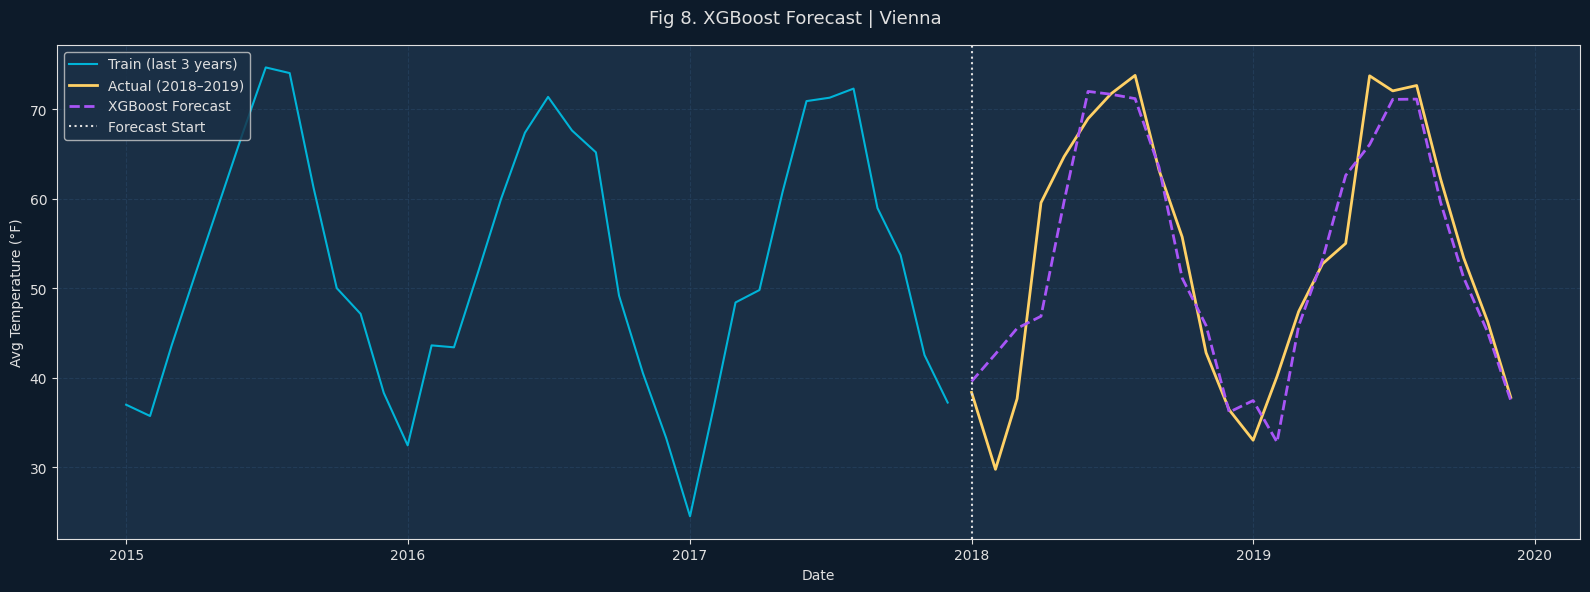

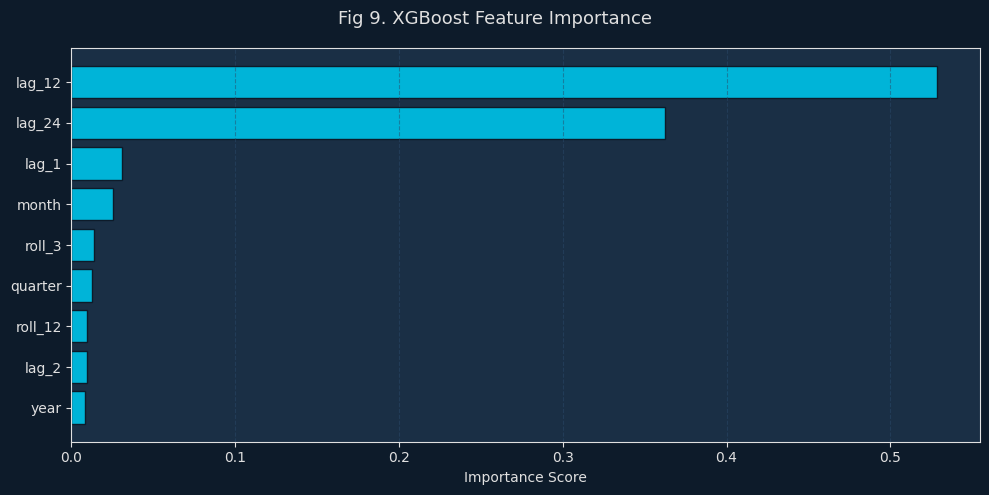


───────────────────────────────────
  XGBoost Forecast Metrics
───────────────────────────────────
  MAE  : 3.82 °F
  RMSE : 5.29 °F
  MAPE : 8.19 %
───────────────────────────────────


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Feature Engineering
def create_features(df):
    df = df.copy()
    df['month']        = df.index.month
    df['year']         = df.index.year
    df['quarter']      = df.index.quarter
    # Lag features, past values as predictors
    df['lag_1']        = df['AvgTemperature'].shift(1)   # 1 month ago
    df['lag_2']        = df['AvgTemperature'].shift(2)   # 2 months ago
    df['lag_12']       = df['AvgTemperature'].shift(12)  # same month last year
    df['lag_24']       = df['AvgTemperature'].shift(24)  # same month 2 years ago
    # Rolling mean features
    df['roll_3']       = df['AvgTemperature'].shift(1).rolling(3).mean()
    df['roll_12']      = df['AvgTemperature'].shift(1).rolling(12).mean()
    return df

# full dataset with features
full_df = monthly.to_frame()
full_df = create_features(full_df)
full_df = full_df.dropna()

# Split features and target
FEATURES = ['month', 'year', 'quarter',
            'lag_1', 'lag_2', 'lag_12', 'lag_24',
            'roll_3', 'roll_12']
TARGET   = 'AvgTemperature'

X_train = full_df[:'2017-12'][FEATURES]
y_train = full_df[:'2017-12'][TARGET]
X_test  = full_df['2018-01':][FEATURES]
y_test  = full_df['2018-01':][TARGET]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

# Fitting XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("XGBoost model fitted successfully")

# Forecast
xgb_pred = xgb_model.predict(X_test)
xgb_pred = pd.Series(xgb_pred, index=y_test.index)

# Plotting the forecast
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Fig 8. XGBoost Forecast | Vienna', fontsize=13)

ax.plot(train['2015':].index, train['2015':].values,
        color=CYAN, lw=1.5, label='Train (last 3 years)')

ax.plot(y_test.index, y_test.values,
        color=YELLOW, lw=2, label='Actual (2018–2019)')

ax.plot(xgb_pred.index, xgb_pred.values,
        color='#a855f7', lw=2, linestyle='--', label='XGBoost Forecast')

ax.axvline(pd.Timestamp('2018-01-01'), color=WHITE, lw=1.5,
           linestyle=':', label='Forecast Start')
ax.set_ylabel('Avg Temperature (°F)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance Plot
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Fig 9. XGBoost Feature Importance', fontsize=13)

importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors = [PINK if i == importance_df['Importance'].idxmax()
          else CYAN for i in importance_df.index]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=CYAN, edgecolor=DARK)
ax.set_xlabel('Importance Score')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

# Metrics
mae_x  = mean_absolute_error(y_test, xgb_pred)
rmse_x = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_x = np.mean(np.abs((y_test.values - xgb_pred.values) / y_test.values)) * 100

print(f"\n{'─'*35}")
print(f"  XGBoost Forecast Metrics")
print(f"{'─'*35}")
print(f"  MAE  : {mae_x:.2f} °F")
print(f"  RMSE : {rmse_x:.2f} °F")
print(f"  MAPE : {mape_x:.2f} %")
print(f"{'─'*35}")


## Final Comparison Plot and Evaluation Table

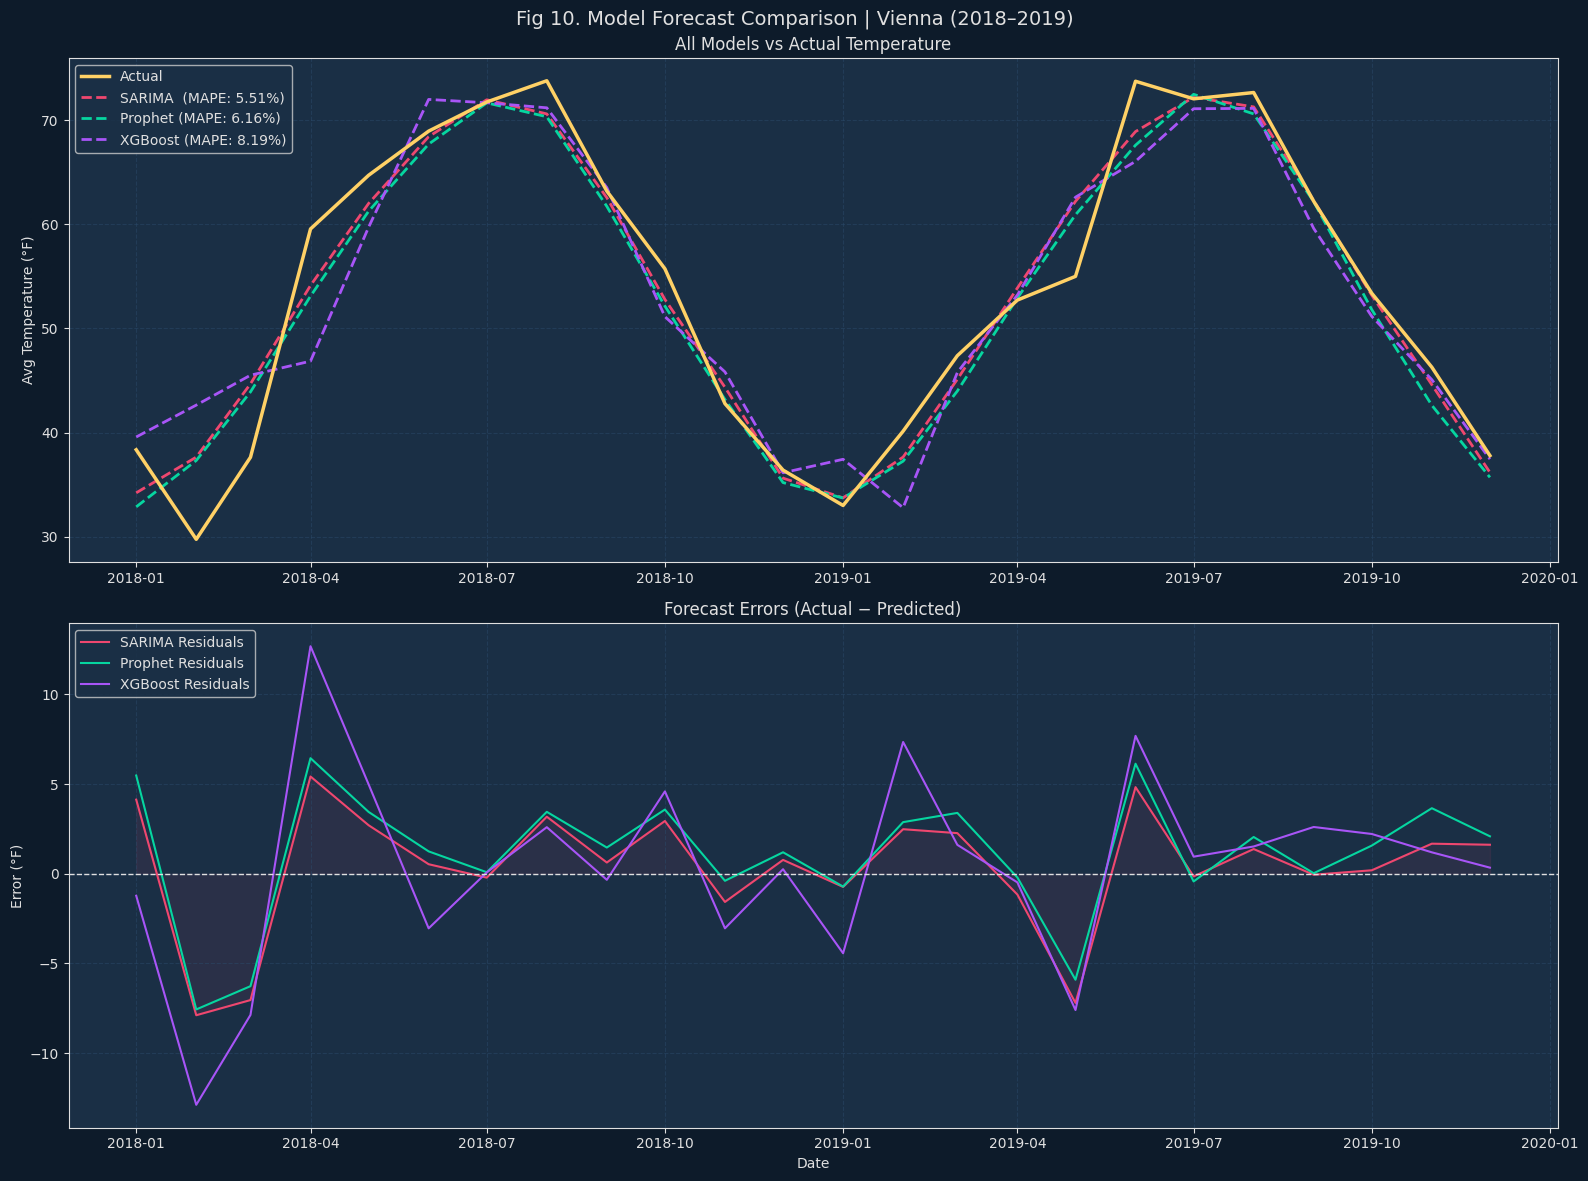

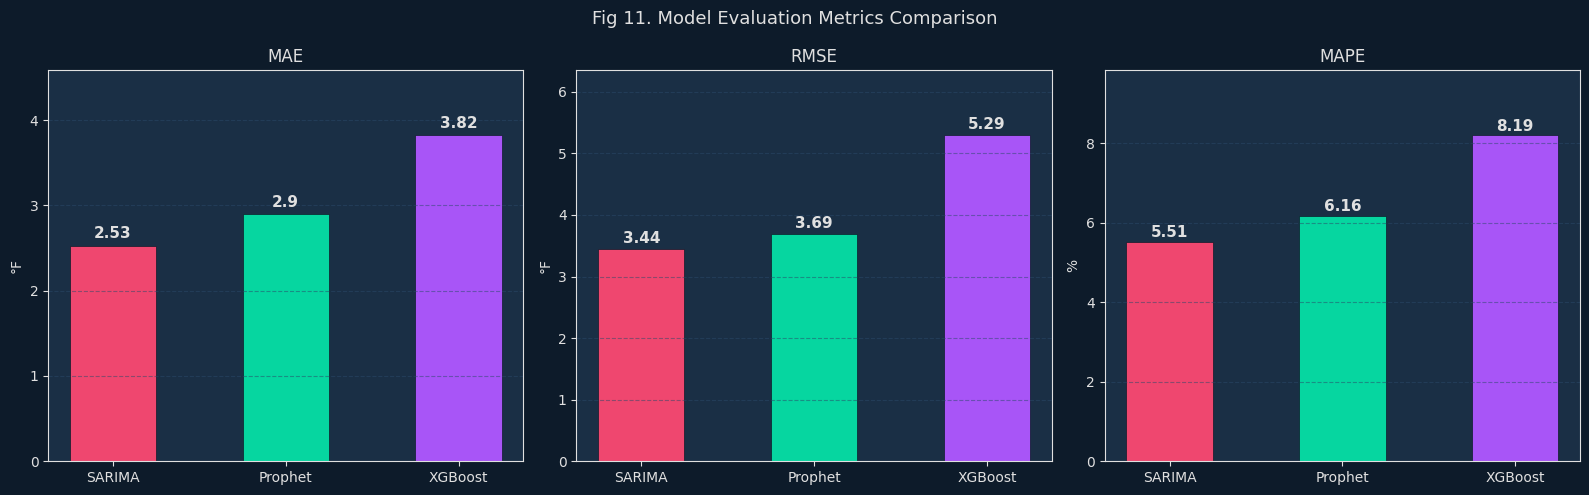


════════════════════════════════════════════════════
  Model             MAE     RMSE     MAPE   Rank
════════════════════════════════════════════════════
  SARIMA          2.53°    3.44°    5.51%   1st
  Prophet         2.90°    3.69°    6.16%   2nd
  XGBoost         3.82°    5.29°    8.19%   3rd
════════════════════════════════════════════════════


In [ ]:
# Fig 10: All 3 Models vs Actual
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Fig 10. Model Forecast Comparison | Vienna (2018–2019)', fontsize=14)

# Top panel: All forecasts
ax = axes[0]
ax.plot(test.index, test.values,
        color=YELLOW, lw=2.5, label='Actual', zorder=5)
ax.plot(sarima_mean.index, sarima_mean.values,
        color=PINK, lw=2, linestyle='--', label=f'SARIMA  (MAPE: 5.51%)')
ax.plot(prophet_mean.index, prophet_mean.values,
        color='#06d6a0', lw=2, linestyle='--', label=f'Prophet (MAPE: 6.16%)')
ax.plot(xgb_pred.index, xgb_pred.values,
        color='#a855f7', lw=2, linestyle='--', label=f'XGBoost (MAPE: 8.19%)')

ax.set_title('All Models vs Actual Temperature', color=WHITE)
ax.set_ylabel('Avg Temperature (°F)')
ax.legend(loc='upper left')
ax.grid(True)

# Bottom panel: Residuals (error) for each model
ax2 = axes[1]
sarima_resid  = test.values - sarima_mean.values
prophet_resid = test.values - prophet_mean.values
xgb_resid     = y_test.values - xgb_pred.values

ax2.plot(test.index, sarima_resid,
         color=PINK,      lw=1.5, label='SARIMA Residuals')
ax2.plot(test.index, prophet_resid,
         color='#06d6a0', lw=1.5, label='Prophet Residuals')
ax2.plot(test.index, xgb_resid,
         color='#a855f7', lw=1.5, label='XGBoost Residuals')
ax2.axhline(0, color=WHITE, lw=1, linestyle='--')
ax2.fill_between(test.index, sarima_resid, 0,
                 color=PINK, alpha=0.08)

ax2.set_title('Forecast Errors (Actual − Predicted)', color=WHITE)
ax2.set_ylabel('Error (°F)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Fig 11: Metrics Bar Chart
metrics_df = pd.DataFrame({
    'Model':  ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE':    [2.53, 2.90, 3.82],
    'RMSE':   [3.44, 3.69, 5.29],
    'MAPE':   [5.51, 6.16, 8.19]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 11. Model Evaluation Metrics Comparison', fontsize=13)

colors  = [PINK, '#06d6a0', '#a855f7']
metrics = ['MAE', 'RMSE', 'MAPE']
ylabels = ['°F', '°F', '%']

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric],
                  color=colors, edgecolor=DARK, linewidth=0.5, width=0.5)
    # Add value labels on bars
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
    ax.set_title(metric, color=WHITE)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, metrics_df[metric].max() * 1.2)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

# Final Summary Table
print(f"\n{'═'*52}")
print(f"  {'Model':<12} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}   Rank")
print(f"{'═'*52}")
rows = [
    ('SARIMA',  2.53, 3.44, 5.51, '1st'),
    ('Prophet', 2.90, 3.69, 6.16, '2nd'),
    ('XGBoost', 3.82, 5.29, 8.19, '3rd'),
]
for model, mae, rmse, mape, rank in rows:
    print(f"  {model:<12} {mae:>7.2f}° {rmse:>7.2f}° {mape:>7.2f}%   {rank}")
print(f"{'═'*52}")



### Why SARIMA Won
SARIMA is the best performer on this dataset, which is expected.
Vienna's temperature follows a highly regular, stable seasonal
pattern that is exactly the type of series that classical statistical
models were designed for. With 25 years of consistent seasonality,
SARIMA's explicit seasonal differencing and AR terms capture the
structure very efficiently.

### Why Prophet Came Second
Prophet performed close to SARIMA, with a MAPE difference of only
0.65%. Its automatic trend and seasonality decomposition handled
the data well, though it has slightly more flexibility than needed
for such a regular series which can introduce minor overfitting.

### Why XGBoost Came Third
XGBoost's higher error is not a failure, it is a reflection of a fundamental
differenct approach. As a machine learning model it relies entirely
on engineered lag and calendar features rather than modelling time
structure directly. For datasets with irregular patterns, external
variables, or non-linear relationships, XGBoost would likely
outperform both statistical models. Its inclusion here demonstrates
the trade-off between classical and ML approaches to forecasting.

### Residual Analysis
The residual plot confirms SARIMA produces the smallest and most
evenly distributed errors across both forecast years, with no
systematic over or under-prediction pattern visible.